# Lab — Time Series Analysis with the UCI Bike Sharing Dataset

**Module:** Time Series Analysis and Forecasting  
**Estimated Time:** 90–120 minutes  
**Dataset:** UCI Bike Sharing Dataset, `day.csv`  
**Primary Skills:** datetime handling, time series data quality, resampling, rolling averages, seasonality analysis, baseline forecasting, forecast evaluation

---

## Lab Scenario

You are a data analyst for a bike sharing company.

Your manager wants to understand how bike rental demand changes over time and whether simple baseline forecasts can provide a useful starting point for short-term demand planning.

Before building any advanced forecasting model, your job is to complete a practical time series workflow:

1. Load and inspect the dataset.
2. Convert the date column into a proper datetime format.
3. Sort and index the data chronologically.
4. Check whether the time series has missing dates or duplicate timestamps.
5. Explore trend, seasonality, and rolling averages.
6. Build simple baseline forecasts.
7. Evaluate the forecasts with MAE and RMSE.
8. Communicate your findings clearly.

This lab is intentionally focused on workflow and interpretation, not advanced forecasting models.

---

## Dataset Overview

You will use the **UCI Bike Sharing Dataset**.

For this lab, use the file:

```text
day.csv
```

Each row represents one day of bike rental activity.

### Important Columns

| Column | Description |
|---|---|
| `instant` | Record index |
| `dteday` | Date |
| `season` | Season encoded as a number |
| `yr` | Year encoded as `0` or `1` |
| `mnth` | Month number |
| `holiday` | Whether the day was a holiday |
| `weekday` | Day of the week |
| `workingday` | Whether the day was a working day |
| `weathersit` | Weather situation category |
| `temp` | Normalized temperature |
| `atemp` | Normalized feeling temperature |
| `hum` | Normalized humidity |
| `windspeed` | Normalized wind speed |
| `casual` | Count of casual users |
| `registered` | Count of registered users |
| `cnt` | Total rental bike count |

For this lab, your main target column is:

```python
cnt
```

This represents total bike rentals for the day.

---

## Lab Learning Objectives

By the end of this lab, you will be able to:

- Load a real time series dataset into pandas.
- Convert a date column using `pd.to_datetime()`.
- Sort a dataset chronologically.
- Set a datetime column as the DataFrame index.
- Check for duplicate timestamps.
- Check for missing dates in a daily time series.
- Resample daily data into weekly and monthly summaries.
- Use rolling averages to smooth noisy daily data.
- Analyze trend and seasonality.
- Create simple baseline forecasts.
- Evaluate forecasts using MAE and RMSE.
- Explain the limitations of baseline forecasting.

---

---

## Part 1 — Load the Dataset

### Option A: Load from a Local CSV File

Use this option if `day.csv` is already saved in your project folder.

```python
bike = pd.read_csv("day.csv")
```

### Option B: Load Directly from a URL

Use this option if your instructor gives you a direct raw CSV URL.

```python
url = "YOUR_RAW_CSV_URL_HERE"
bike = pd.read_csv(url)
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
RAW = Path("..\data") / "raw"
bike = pd.read_csv(RAW/"day.csv")

In [3]:
bike.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
bike['dteday'].describe()

count            731
unique           731
top       2011-01-01
freq               1
Name: dteday, dtype: object

---
### Questions

Answer these in a markdown cell:

1. How many rows are in the dataset?
#### 731 rows
3. What does one row represent?
#### Each row is one day's information on weather, riders etc
5. Which column contains the date?
#### dteday has the date
7. Which column contains the total number of rentals?
#### cnt is total
9. Is the date column already stored as a datetime type?
#### no, its read as a string

---

## Part 2 — Create a Proper Datetime Index

The column `dteday` contains the date, but pandas may initially read it as text.

### Tasks:

1. Convert `dteday` to Datetime

2. Sort by Date

3. Set the Date as the Index

### Questions

Answer these in a markdown cell:

1. Why do we convert `dteday` with `pd.to_datetime()`?
#### we neeed the dteday to be in a format that python recognizes as date time to plot and do analysis correctly
3. Why should time series data be sorted before analysis?
#### unlike random data, we need this sorted into chronological order to make sense of patterns
5. What changed after setting `dteday` as the index?
#### our indexes are now in chronological order as well!  yipee!

In [6]:
# bike["dteday"]=pd.to_datetime('dteday')
bike["dteday"] = pd.to_datetime(bike["dteday"], format="%Y-%m-%d")

In [7]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [8]:
bike = bike.sort_values(by="dteday")


In [9]:
bike = bike.set_index("dteday")

In [10]:
bike.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
dteday,,,,,,,,,,,,,,,
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


---

## Part 3 — Time Series Data Quality Checks

Before analyzing a time series, check whether the time index is complete, unique, sorted, and regular.

### Tasks 

1. Check for Duplicate Timestamps
2. Check Whether the Index Is Sorted
3. Infer the Frequency
4. Check for Missing Dates

### Questions

Answer these in a markdown cell:

1. Are there duplicate dates?
#### no duplicates
2. 
3. Is the index sorted chronologically?
#### True - yes
5. Does pandas detect a daily frequency?
#### Yes 'D'
6. Are any dates missing?
#### no dates missing
8. Why are missing timestamps different from missing values?
#### a missing timestamp would be a whole row missing, a missing value has that "row" / date, but doesn't have any information in each of the colums or just some of the column numbers are missing


In [11]:
bike.duplicated().sum()

np.int64(0)

In [12]:
bike.index.is_monotonic_increasing

True

In [13]:
pd.infer_freq(bike.index)

'D'

In [14]:
expected_days = pd.date_range(
    start=bike.index.min(),
    end=bike.index.max(),
    freq='D'
)
missing_days = expected_days.difference(bike.index)

print(expected_days, missing_days)

DatetimeIndex(['2011-01-01', '2011-01-02', '2011-01-03', '2011-01-04',
               '2011-01-05', '2011-01-06', '2011-01-07', '2011-01-08',
               '2011-01-09', '2011-01-10',
               ...
               '2012-12-22', '2012-12-23', '2012-12-24', '2012-12-25',
               '2012-12-26', '2012-12-27', '2012-12-28', '2012-12-29',
               '2012-12-30', '2012-12-31'],
              dtype='datetime64[ns]', length=731, freq='D') DatetimeIndex([], dtype='datetime64[ns]', freq='D')


## Part 4 — Initial Time Series Visualization

### Tasks 

1. Plot Daily Bike Rentals

### Questions

Answer these in a markdown cell:

1. Does bike rental demand appear to change over time?
#### yes, bike rental varies between 2000 and 8000 over time
3. Do you notice any repeating patterns?
#### yes, there is a hump - two cycles in our data
5. Does the data look noisy at the daily level?
#### yes, noisy at the daily level
7. Are there any sudden drops or spikes worth investigating?
#### yes - what is going on at the bottom and top of our two humps

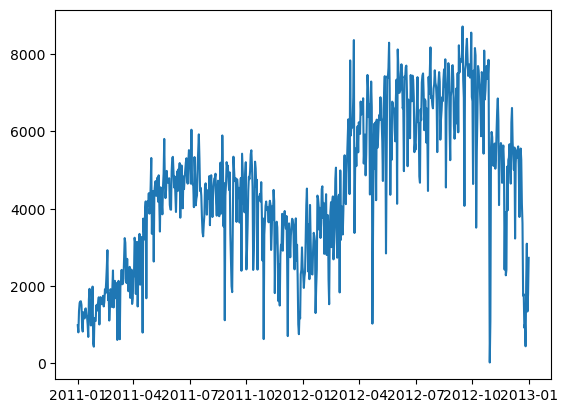

In [15]:
plt.plot(bike.index, bike["cnt"])

## Part 5 — Resampling Daily Data

Daily data can be noisy. Resampling helps summarize the data at a different time level.

### Tasks 

1. Weekly Total Rentals
2. Monthly Total Rentals
3. Monthly Average Daily Rentals

### Questions

Answer these in a markdown cell:

1. What question does weekly total rentals answer?
#### how many total weekly rentals over time - not as messy as daily, still have good info
3. What question does monthly total rentals answer?
#### how many total monthly rentals - just 12 points per month, not that helpful
5. What question does monthly average daily rentals answer?
#### cleans out the weekend/bad weather informion
7. How does resampling change what you can see in the data?
#### it helps with trends and changes with weather when you sum and average
9. Which version is easier to interpret: daily, weekly, or monthly? Why?
#### i like the weekly average - i think it can give a better feeling for weather season etc
---

In [16]:
Weekly_Total = bike['cnt'].resample("W").sum()
Monthly_Total = bike['cnt'].resample('ME').sum()
Monthly_Ave = bike['cnt'].resample('ME').mean()

<Axes: title={'center': 'Weekly Bike Rentals'}, xlabel='dteday'>

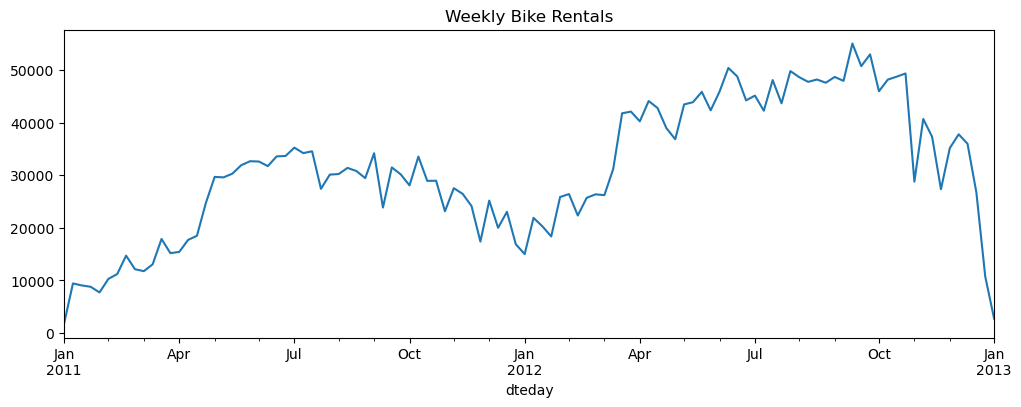

In [17]:
Weekly_Total.plot(figsize=(12,4), title="Weekly Bike Rentals")

<Axes: title={'center': 'Monthly Total Rentals'}, xlabel='dteday'>

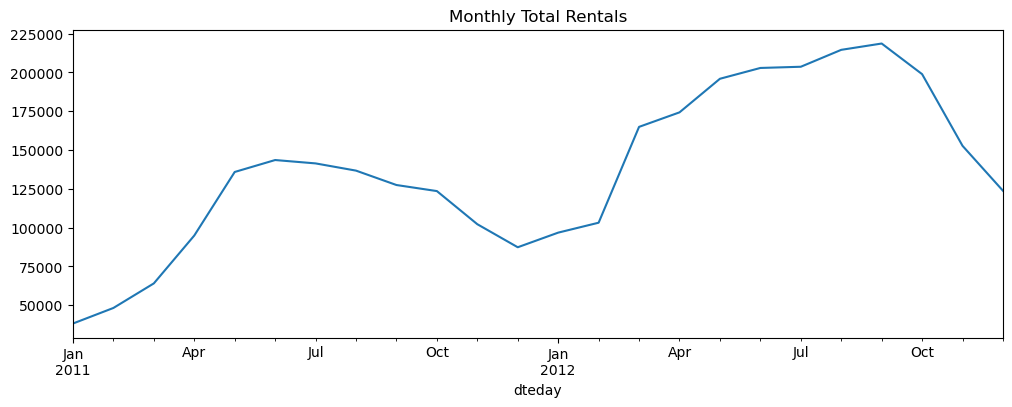

In [18]:
Monthly_Total.plot(figsize=(12,4), title="Monthly Total Rentals")

<Axes: title={'center': 'Monthly Average Daily Rentals'}, xlabel='dteday'>

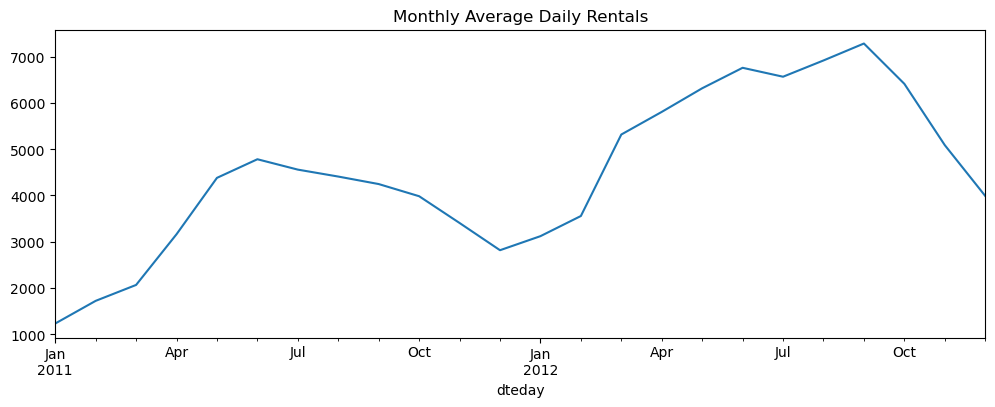

In [19]:
Monthly_Ave.plot(figsize=(12,4), title="Monthly Average Daily Rentals")


---
## Part 6 — Rolling Averages

Rolling averages help smooth short-term fluctuations.

### Tasks 

1. Create Rolling Average Columns for 7 and 30 days
2. Plot Daily Rentals with Rolling Averages

### Questions

Answer these in a markdown cell:

1. What does the 7-day rolling average smooth out?
#### daily fluctuations due to weather and holidays - makes seasonal more obvious
3. What does the 30-day rolling average reveal?
#### seasonal trends
5. Which line is most useful for seeing short-term changes?
#### 7-day
7. Which line is most useful for seeing the larger trend?
#### 30-day
9. Why do the first few rolling average values appear as missing?
#### because you can't have an average until you actually have 7 days or 30 full days
---

In [20]:
bike["rolling_7_day_avg"] = bike["cnt"].rolling(window=7).mean()

In [21]:
bike["rolling_30_day_avg"] = bike["cnt"].rolling(window=30).mean()

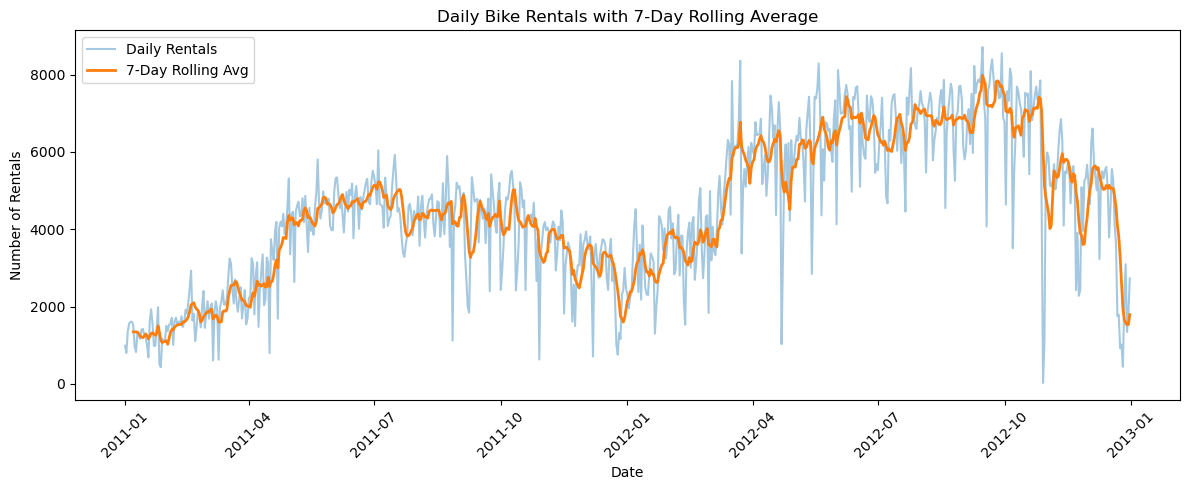

In [22]:
plt.figure(figsize=(12,5))

# Daily rentals
plt.plot(bike.index, bike["cnt"], label="Daily Rentals", alpha=0.4)

# Rolling average
plt.plot(bike.index, bike["rolling_7_day_avg"], label="7-Day Rolling Avg", linewidth=2)

plt.title("Daily Bike Rentals with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Number of Rentals")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

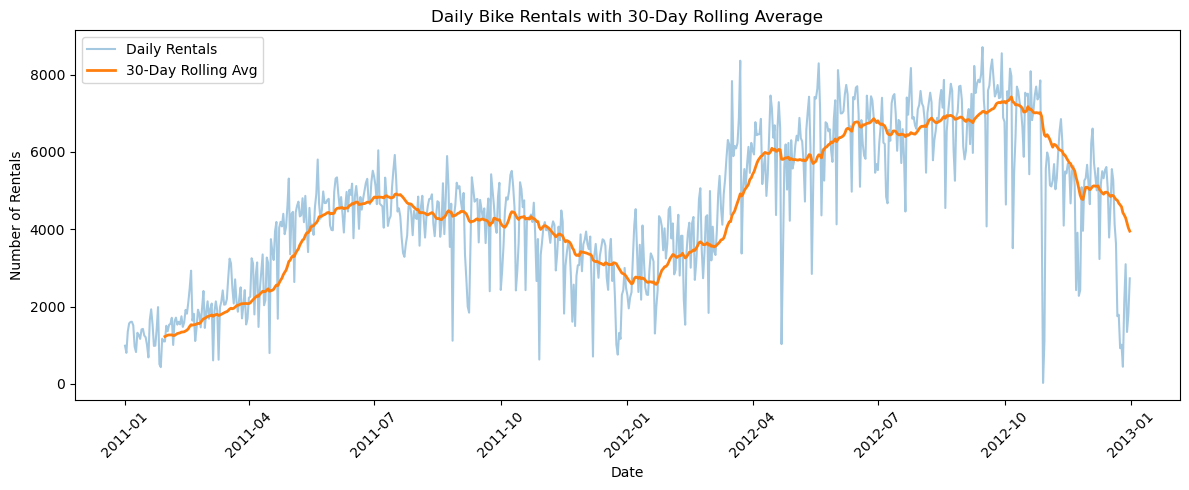

In [23]:
plt.figure(figsize=(12,5))

# Daily data (noisy)
plt.plot(bike.index, bike["cnt"], label="Daily Rentals", alpha=0.4)

# 30-day rolling average (smooth trend)
plt.plot(bike.index, bike["rolling_30_day_avg"], label="30-Day Rolling Avg", linewidth=2)

plt.title("Daily Bike Rentals with 30-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Number of Rentals")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

---

## Part 7 — Date Part Features

Extracting date parts helps us analyze calendar-based patterns.

### Tasks 

1. Create Date Part Columns (Year, Month, Day, etc.)



In [24]:
bike_rider_features = bike.copy()

bike_rider_features["day_of_week"] = bike_rider_features.index.day_name()
bike_rider_features["month"] = bike_rider_features.index.month_name()
bike_rider_features["month_number"] = bike_rider_features.index.month

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

bike_rider_features["season"] = bike_rider_features.index.month.map(get_season)
bike_rider_features.groupby("season")["cnt"].mean()

season
Fall      5072.384615
Spring    4509.239130
Summer    5665.673913
Winter    2747.629834
Name: cnt, dtype: float64

In [25]:
bike_rider_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2011-01-01 to 2012-12-31
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   instant             731 non-null    int64  
 1   season              731 non-null    object 
 2   yr                  731 non-null    int64  
 3   mnth                731 non-null    int64  
 4   holiday             731 non-null    int64  
 5   weekday             731 non-null    int64  
 6   workingday          731 non-null    int64  
 7   weathersit          731 non-null    int64  
 8   temp                731 non-null    float64
 9   atemp               731 non-null    float64
 10  hum                 731 non-null    float64
 11  windspeed           731 non-null    float64
 12  casual              731 non-null    int64  
 13  registered          731 non-null    int64  
 14  cnt                 731 non-null    int64  
 15  rolling_7_day_avg   725 non-null    fl

---

## Part 8 — Analyze Seasonality

### Tasks 

1. Average Rentals by Month
2. Average Rentals by Day of Week
3. Compare Rentals by Season

### Questions

Answer these in a markdown cell:

1. Which months have the highest average rentals?
#### June has highest average monthly rental
3. Which months have the lowest average rentals?
#### January is lowest
5. Are rentals higher on weekdays or weekends?
#### Weekdays
7. Which season has the highest rental counts?
#### Summer has highest rental counts
9. What seasonal patterns do you notice?
#### Summer and fall are most popular
---

In [26]:
# Average passengers by month
month_order = [
    "January", "February", "March", "April", "May", "June", "July",
    "August", "September", "October", "November", "December"
]

avg_riders_by_month = (
    bike_rider_features.groupby('month')['cnt'].mean().reindex(month_order)
)

avg_riders_by_month

month
January      2176.338710
February     2655.298246
March        3692.258065
April        4484.900000
May          5349.774194
June         5772.366667
July         5563.677419
August       5664.419355
September    5766.516667
October      5199.225806
November     4247.183333
December     3403.806452
Name: cnt, dtype: float64

In [27]:
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_riders_by_day = (
    bike_rider_features.groupby('day_of_week')['cnt'].mean().reindex(day_order)
)

avg_riders_by_day

day_of_week
Monday       4338.123810
Tuesday      4510.663462
Wednesday    4548.538462
Thursday     4667.259615
Friday       4690.288462
Saturday     4550.542857
Sunday       4228.828571
Name: cnt, dtype: float64

In [28]:
weekend_avg = bike_rider_features[
    bike_rider_features["day_of_week"].isin(["Saturday", "Sunday"])
]["cnt"].mean()
weekday_avg = bike_rider_features[
    ~bike_rider_features["day_of_week"].isin(["Saturday", "Sunday"])
]["cnt"].mean()
weekday_avg, weekend_avg

(np.float64(4550.5662188099805), np.float64(4389.685714285714))

In [29]:
bike_rider_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2011-01-01 to 2012-12-31
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   instant             731 non-null    int64  
 1   season              731 non-null    object 
 2   yr                  731 non-null    int64  
 3   mnth                731 non-null    int64  
 4   holiday             731 non-null    int64  
 5   weekday             731 non-null    int64  
 6   workingday          731 non-null    int64  
 7   weathersit          731 non-null    int64  
 8   temp                731 non-null    float64
 9   atemp               731 non-null    float64
 10  hum                 731 non-null    float64
 11  windspeed           731 non-null    float64
 12  casual              731 non-null    int64  
 13  registered          731 non-null    int64  
 14  cnt                 731 non-null    int64  
 15  rolling_7_day_avg   725 non-null    fl

---

## Part 9 — Chronological Train/Test Split

Forecasting requires training on the past and testing on the future.

Do **not** use a random train/test split.

### Tasks 

1. Create the your forecasting Series
2. Use the Last 60 Days as the Test Set
3. Plot the Split

### Questions

Answer these in a markdown cell:

1. What date range is used for training?
#### from Jan 1, 2011 to May 31, 2012
3. What date range is used for testing?
#### June 1 2012 to Dec 31 2012 for testing
5. Why is a random split inappropriate for time series forecasting?
#### a random split might test past data on present data - doesn't make sense to go "backwords" in time
---

In [30]:
bike.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,rolling_7_day_avg,rolling_30_day_avg
dteday,,,,,,,,,,,,,,,,,
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,NaN,NaN
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,NaN,NaN
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,NaN,NaN
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,NaN,NaN
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,NaN,NaN


In [31]:
bike.tail()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,rolling_7_day_avg,rolling_30_day_avg
dteday,,,,,,,,,,,,,,,,,
2012-12-27,727,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114,1663.857143,4366.766667
2012-12-28,728,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095,1588.428571,4294.600000
2012-12-29,729,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341,1530.142857,4161.866667
2012-12-30,730,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796,1531.428571,4032.800000
2012-12-31,731,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729,1789.857143,3950.733333


In [32]:
forecast_riders=bike[['cnt']].copy()

In [33]:
train = forecast_riders.loc[:"2012-05-31"].copy()
test = forecast_riders.loc["2012-06-01":].copy()

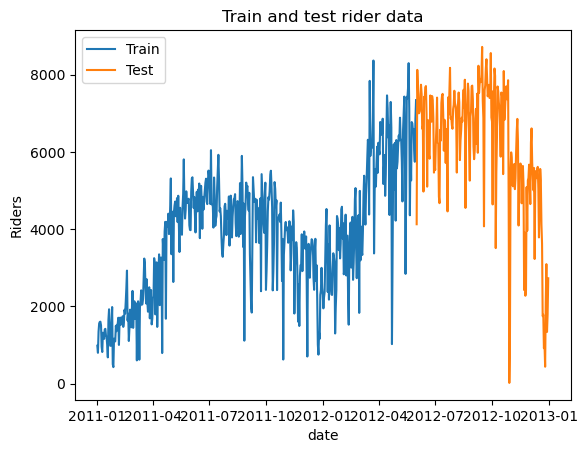

In [34]:
# Plot the train test split
plt.plot(train.index, train['cnt'], label='Train')
plt.plot(test.index, test['cnt'], label='Test')
plt.xlabel("date")
plt.ylabel("Riders")
plt.title("Train and test rider data")
plt.legend();

---

# For parts 10 and beyond, sample code is provided with the intention to help you focus more on the questions to answer. Running the code is still required.


---

## Part 10 — Baseline Forecast 1: Naive Forecast

A naive forecast predicts that every future value will equal the last observed training value.

```python
seasonal_weekly_values = []

for date in test.index:
    previous_week_date = date - pd.DateOffset(days=7)
    seasonal_weekly_values.append(series.loc[previous_week_date])

seasonal_weekly_forecast = pd.Series(
    data=seasonal_weekly_values,
    index=test.index
)
```

```python
seasonal_weekly_forecast.head(10)
```

```python
plt.figure(figsize=(14, 5))

sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=seasonal_weekly_forecast.index, y=seasonal_weekly_forecast.values, label="Seasonal Weekly Naive Forecast")

plt.title("Seasonal Weekly Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()
```

### Question

Answer in a markdown cell:

1. What assumption does the naive forecast make?
2. Does that assumption seem reasonable for this dataset? Why or why not?


In [45]:
seasonal_weekly_values = []

for date in test.index:
    previous_week_date = date - pd.DateOffset(days=7)
    seasonal_weekly_values.append(bike.loc[previous_week_date])

seasonal_weekly_forecast = pd.Series(
    data=seasonal_weekly_values,
    index=test.index
)

In [48]:
seasonal_weekly_forecast.head(10)

dteday
2012-06-01    instant                511.000000
season      ...
2012-06-02    instant                512.000000
season      ...
2012-06-03    instant                513.000000
season      ...
2012-06-04    instant                514.000000
season      ...
2012-06-05    instant                515.000000
season      ...
2012-06-06    instant                516.000000
season      ...
2012-06-07    instant                517.000000
season      ...
2012-06-08    instant                518.000000
season      ...
2012-06-09    instant                519.000000
season      ...
2012-06-10    instant                520.000000
season      ...
dtype: object

In [38]:
plt.figure(figsize=(14, 5))

sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=seasonal_weekly_forecast.index, y=seasonal_weekly_forecast.values, label="Seasonal Weekly Naive Forecast")

plt.title("Seasonal Weekly Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()

ValueError: Per-column arrays must each be 1-dimensional

<Figure size 1400x500 with 0 Axes>

---

## Part 11 — Baseline Forecast 2: 7-Day Average Forecast

A 7-day average forecast uses the average of the final week of training data and repeats it across the test period.

### Task

```python
last_7_day_average = train.tail(7).mean()

average_7_day_forecast = pd.Series(
    data=last_7_day_average,
    index=test.index
)
```

```python
average_7_day_forecast.head()
```

```python
plt.figure(figsize=(14, 5))

sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=average_7_day_forecast.index, y=average_7_day_forecast.values, label="7-Day Average Forecast")

plt.title("7-Day Average Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()
```

### Question

Answer in a markdown cell:

1. How is this forecast different from the naive forecast?
2. What information does it use?
3. What information does it ignore?

---

---

## Part 12 — Baseline Forecast 3: Seasonal Weekly Naive Forecast

Because this is daily data, demand may follow a weekly pattern.

A seasonal weekly naive forecast predicts each test day using the value from 7 days earlier.

### Task

```python
seasonal_weekly_values = []

for date in test.index:
    previous_week_date = date - pd.DateOffset(days=7)
    seasonal_weekly_values.append(series.loc[previous_week_date])

seasonal_weekly_forecast = pd.Series(
    data=seasonal_weekly_values,
    index=test.index
)
```

```python
seasonal_weekly_forecast.head(10)
```

```python
plt.figure(figsize=(14, 5))

sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=seasonal_weekly_forecast.index, y=seasonal_weekly_forecast.values, label="Seasonal Weekly Naive Forecast")

plt.title("Seasonal Weekly Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()
```

### Question

Answer in a markdown cell:

1. Why might a 7-day seasonal forecast make sense for daily bike rental data?
2. What pattern is this forecast trying to capture?
3. When might this forecast fail?

---

## Part 13 — Compare Baseline Forecasts

### Task

```python
forecast_comparison = pd.DataFrame({
    "actual": test,
    "naive": naive_forecast,
    "average_7_day": average_7_day_forecast,
    "seasonal_weekly_naive": seasonal_weekly_forecast
})

forecast_comparison.head()
```

```python
plt.figure(figsize=(14, 6))

sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="actual", label="Actual")
sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="naive", label="Naive")
sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="average_7_day", label="7-Day Average")
sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="seasonal_weekly_naive", label="Seasonal Weekly Naive")

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()
```

### Questions

Answer these in a markdown cell:

1. Which forecast looks most realistic visually?
2. Which forecast appears too flat?
3. Which forecast best follows short-term movement?
4. Do any forecasts appear to consistently overpredict or underpredict?



## Part 14 — Evaluate Forecast Accuracy

Use MAE and RMSE to compare the baseline forecasts.

### Task 1: Define an Evaluation Function

```python
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    
    return {
        "MAE": mae,
        "RMSE": rmse
    }
```

### Task 2: Evaluate Each Forecast

```python
naive_metrics = evaluate_forecast(test, naive_forecast)
average_7_day_metrics = evaluate_forecast(test, average_7_day_forecast)
seasonal_weekly_metrics = evaluate_forecast(test, seasonal_weekly_forecast)
```

```python
results = pd.DataFrame({
    "Naive": naive_metrics,
    "7-Day Average": average_7_day_metrics,
    "Seasonal Weekly Naive": seasonal_weekly_metrics
}).T

results
```

```python
results.sort_values("MAE")
```

### Questions

Answer these in a markdown cell:

1. Which forecast had the lowest MAE?
2. Which forecast had the lowest RMSE?
3. Did the same forecast perform best on both metrics?
4. Did the metric results match what you saw visually?
5. Which baseline would you recommend as the best simple forecast?

---

## Part 15 — Forecast Error Analysis

Forecast errors can show whether a model is consistently too high or too low.

### Task 1: Calculate Errors

```python
forecast_comparison["naive_error"] = forecast_comparison["actual"] - forecast_comparison["naive"]
forecast_comparison["average_7_day_error"] = forecast_comparison["actual"] - forecast_comparison["average_7_day"]
forecast_comparison["seasonal_weekly_error"] = forecast_comparison["actual"] - forecast_comparison["seasonal_weekly_naive"]
```

```python
forecast_comparison.head()
```

### Task 2: Plot Seasonal Weekly Forecast Errors

```python
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=forecast_comparison,
    x=forecast_comparison.index,
    y="seasonal_weekly_error",
    marker="o"
)

plt.axhline(0, linestyle="--")
plt.title("Seasonal Weekly Naive Forecast Errors")
plt.xlabel("Date")
plt.ylabel("Actual - Forecast")
plt.show()
```

### Questions

Answer these in a markdown cell:

1. What does a positive error mean?
2. What does a negative error mean?
3. Was the seasonal weekly forecast usually too high, too low, or mixed?
4. Are there any days where the forecast made a large mistake?
5. What might explain large forecast errors?

---

---

## Part 17 — Final Written Interpretation

Write a short conclusion that answers the following questions.

### Required Questions

1. What is the overall trend in bike rentals?
2. What seasonal or calendar patterns did you find?
3. How did weather appear to relate to rental demand?
4. Which baseline forecast performed best?
5. Why do you think that forecast performed best?
6. What are the limitations of these baseline forecasts?
7. What additional information or modeling approach might improve future forecasts?

### Example Format

```text
The bike sharing data shows that rental demand changes over time and appears to have seasonal patterns. Rentals tend to be higher during ______ and lower during ______. The rolling averages helped reveal ______. Among the baseline forecasts, ______ performed best based on ______. This likely happened because ______. However, these baseline forecasts are limited because ______. A stronger future model might include ______.
```


---

There are some optional extensions at the end of the [README](../README.md) that you're encouraged to try!